# [SM-TCSR 실습 04] 지속시간 기하 $\text{TD}(\lambda)$와 시간 지평선 불변성

> **학습 목표**: 
> 1. 이산형 $\lambda^k$와 지속시간 기하 감쇄 $\lambda_j = \lambda^{\Delta t_j / \delta_s}$의 차이를 확인합니다.
> 2. 방문 빈도가 다른 두 환자군에서 부트스트랩 반감기가 어떻게 보존되는지 검증합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

delta_s = 1.0 # 1시간
lam_base = 0.6

# 시나리오 A: 집중 관측 환자 (1시간 간격 방문, dt = 1.0h)
time_A = np.arange(0, 24, 1.0)
steps_A = len(time_A)
# 이산형 감쇄: lambda^k
discrete_decay_A = lam_base ** np.arange(steps_A)
# 지속시간 기하 감쇄: lambda^(dt/delta_s)
duration_decay_A = lam_base ** (time_A / delta_s)

# 시나리오 B: 간헐 관측 환자 (6시간 간격 방문, dt = 6.0h)
time_B = np.arange(0, 24, 6.0)
steps_B = len(time_B)
discrete_decay_B = lam_base ** np.arange(steps_B)
duration_decay_B = lam_base ** (time_B / delta_s)


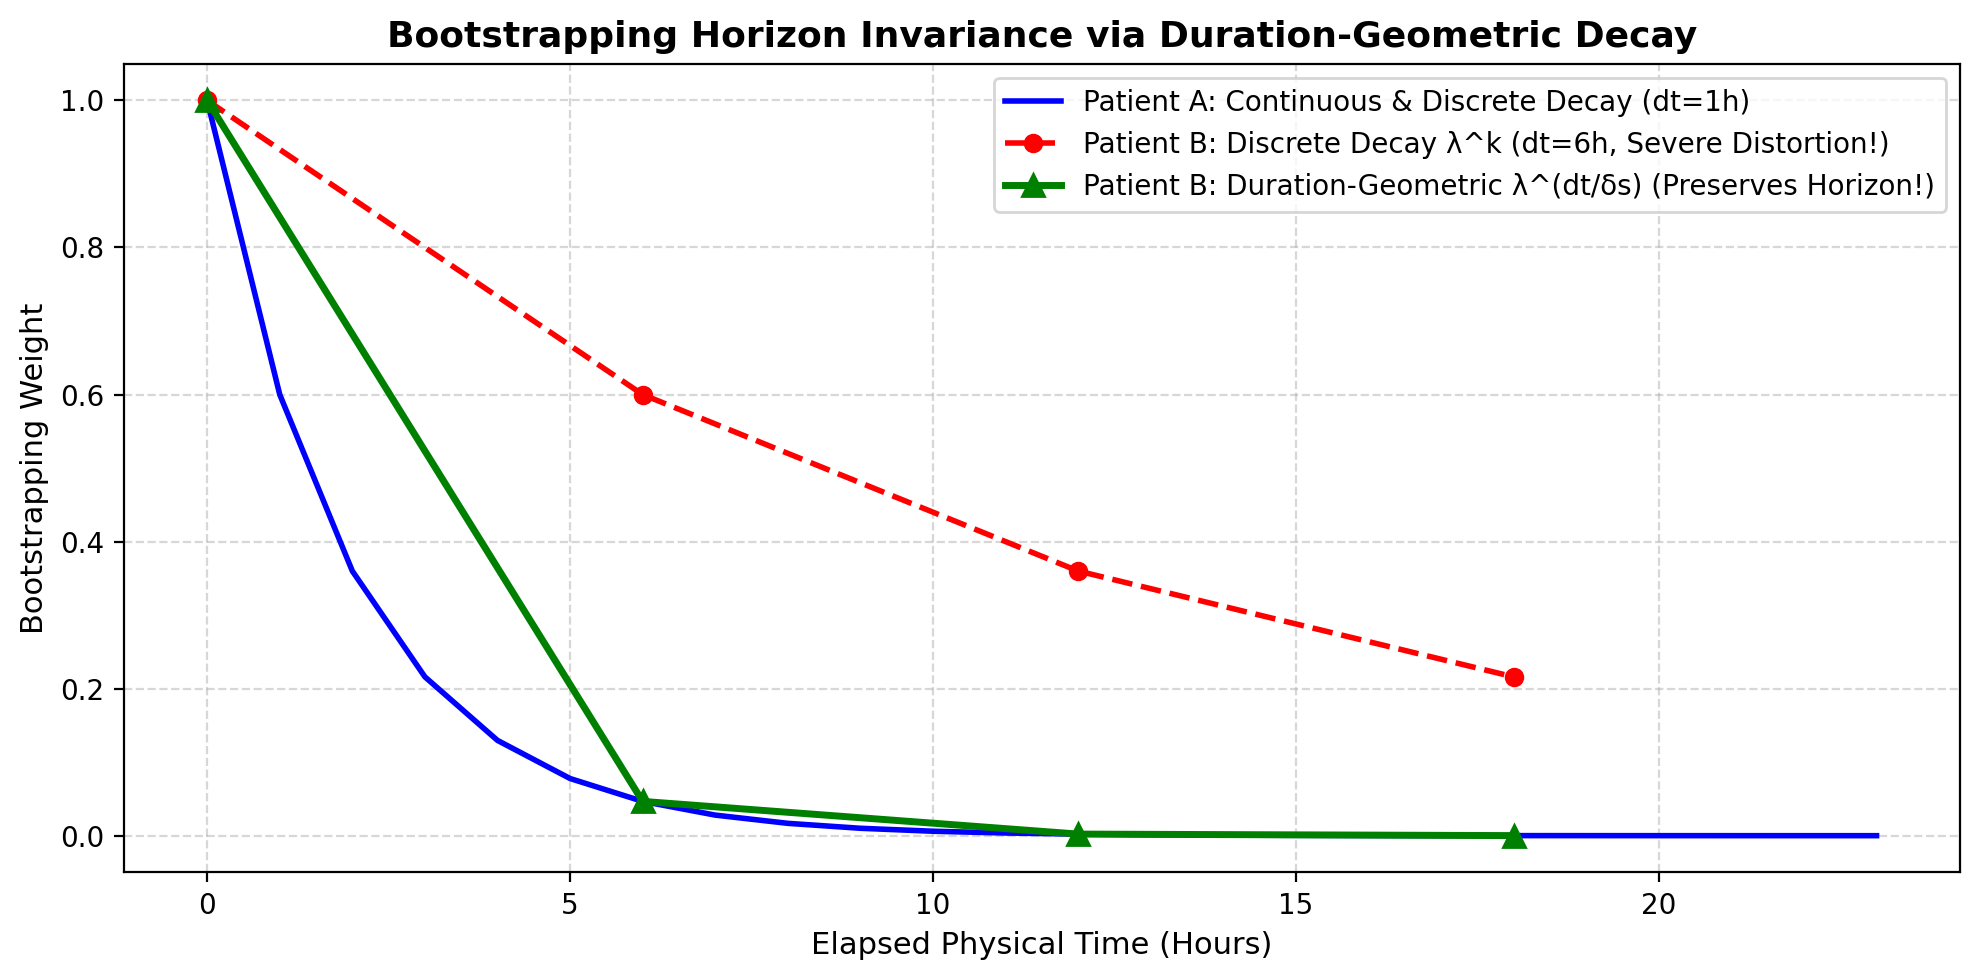

In [2]:
plt.figure(figsize=(10, 5), dpi=200)

plt.plot(time_A, discrete_decay_A, 'b-', label='Patient A: Continuous & Discrete Decay (dt=1h)', lw=2)
plt.plot(time_B, discrete_decay_B, 'ro--', label='Patient B: Discrete Decay λ^k (dt=6h, Severe Distortion!)', lw=2)
plt.plot(time_B, duration_decay_B, 'g^-', label='Patient B: Duration-Geometric λ^(dt/δs) (Preserves Horizon!)', lw=2.5, markersize=8)

plt.title("Bootstrapping Horizon Invariance via Duration-Geometric Decay", fontsize=13, fontweight='bold')
plt.xlabel("Elapsed Physical Time (Hours)", fontsize=11)
plt.ylabel("Bootstrapping Weight", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()
